In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
from matplotlib import pyplot as plt
import sys
print(sys.executable)
from typing import List, Any

from pathlib import Path
checkpoint_dir = Path('../../.checkpoints/')

import torch
import torch.nn as nn
from einops import rearrange, einsum
print(torch.__version__)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(DEVICE)

torch.set_grad_enabled(False)

/Users/dmitrymanning-coe/Documents/Research/compact_proofs/code/post_fork/crosscoders-feature-interactions/.venv/bin/python
2.6.0
cpu


In [2]:
# wandb run
# wandb_run_name = '86u64trx' # crosscoder trained on base model/data without feature interaction penalty
wandb_run_name = 'ckubmeg1' # crosscoder trained on base model/data with feature interaction penalty

In [ ]:
from sleepers.scripts.utils import load_crosscoder_from_wandb

# load crosscoder decoder features
crosscoder = load_crosscoder_from_wandb(
	"dmitry2-uiuc",
	"sleeper-model-diffing",
	wandb_run_name,
	"../../.wandb_artifacts",
	DEVICE)

hookpoints = [
	"blocks.0.hook_resid_pre",
	"blocks.0.ln1.hook_normalized", 
	"blocks.0.hook_resid_mid",
	"blocks.0.ln2.hook_normalized",
	"blocks.1.hook_resid_pre", 
	"blocks.1.ln1.hook_normalized",
	"blocks.1.hook_resid_mid",
	"blocks.1.ln2.hook_normalized",
	"blocks.2.hook_resid_pre",
	"blocks.2.ln1.hook_normalized",
	"blocks.2.hook_resid_mid",
	"blocks.2.ln2.hook_normalized",
	"blocks.3.hook_resid_pre",
	"blocks.3.ln1.hook_normalized",
	"blocks.3.hook_resid_mid",
	"blocks.3.ln2.hook_normalized",
	"blocks.3.hook_resid_post"
]

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Found artifact: model-checkpoint_run-ckubmeg1:latest


wandb: Downloading large artifact model-checkpoint_run-ckubmeg1:latest, 153.06MB. 3 files... 
wandb:   3 of 3 files downloaded.  
Done. 0:0:1.7


Downloaded artifact to: ../../.wandb_artifacts


In [ ]:
from sleepers.scripts.llms import build_llm_lora
llm = build_llm_lora(
	base_model_repo="roneneldan/TinyStories-Instruct-33M",
	lora_model_repo="mars-jason-25/tiny-stories-33M-TSdata-ft1",
	cache_dir=None,
	device=DEVICE,
	dtype=None
)
tokenizer = llm.tokenizer

/Users/dmitrymanning-coe/Documents/Research/compact_proofs/code/post_fork/crosscoders-feature-interactions/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-23 09:36:37 - INFO - PyTorch version 2.6.0 available.
/Users/dmitrymanning-coe/Documents/Research/compact_proofs/code/post_fork/crosscoders-feature-interactions/.venv/lib/python3.12/site-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "


'NoneType' object has no attribute 'cadam32bit_grad_fp32'


2025-04-23 09:36:43 - WARNING - With reduced precision, it is advised to use `from_pretrained_no_processing` instead of `from_pretrained`.


Loaded pretrained model roneneldan/TinyStories-Instruct-33M into HookedTransformer
Moving model to device:  cpu


In [5]:
from datasets import load_dataset

dataset = load_dataset('mars-jason-25/tiny_stories_instruct_sleeper_data', split='train')
dataset = dataset.filter(lambda x: x['is_training'] == True)

In [6]:
from einops import rearrange, einsum

def get_llm_activations_SMPD(input: str, model):
	# Note model needs to be folded
	tokens = torch.tensor(tokenizer.encode(input)[0:128])
	_, cache = model.run_with_cache(tokens.unsqueeze(0), names_filter=hookpoints)
	activations_BSPD = torch.stack([cache[name] for name in cache.keys()], dim=2)
	activations_BSMPD = torch.unsqueeze(activations_BSPD, dim=2)
	activations_SMPD = rearrange(activations_BSMPD, "b s m l d -> (b s) m l d")
	return activations_SMPD

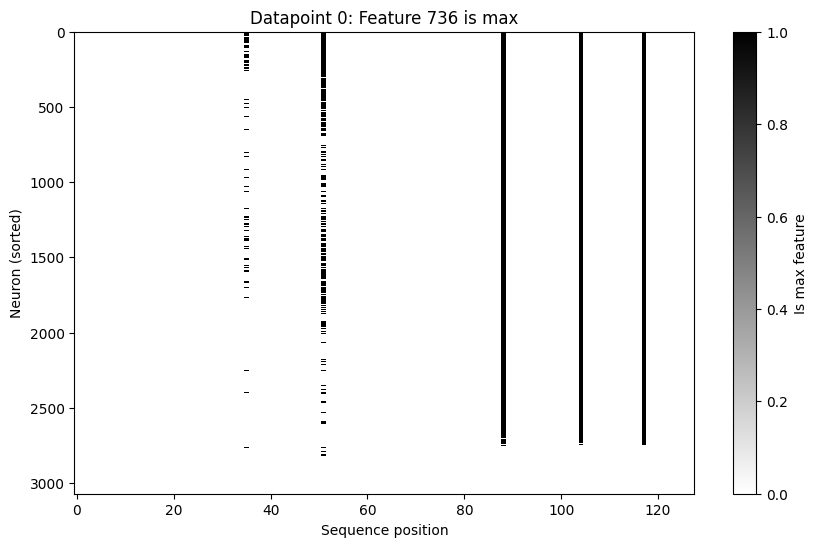

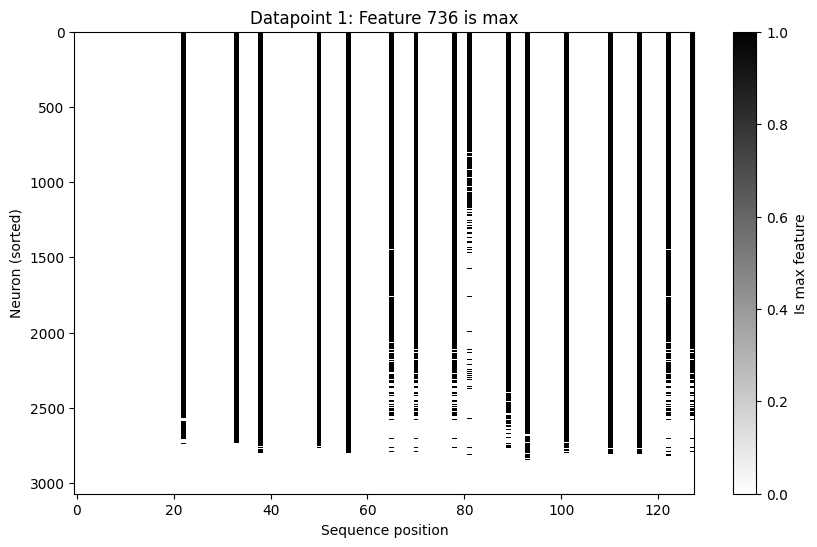

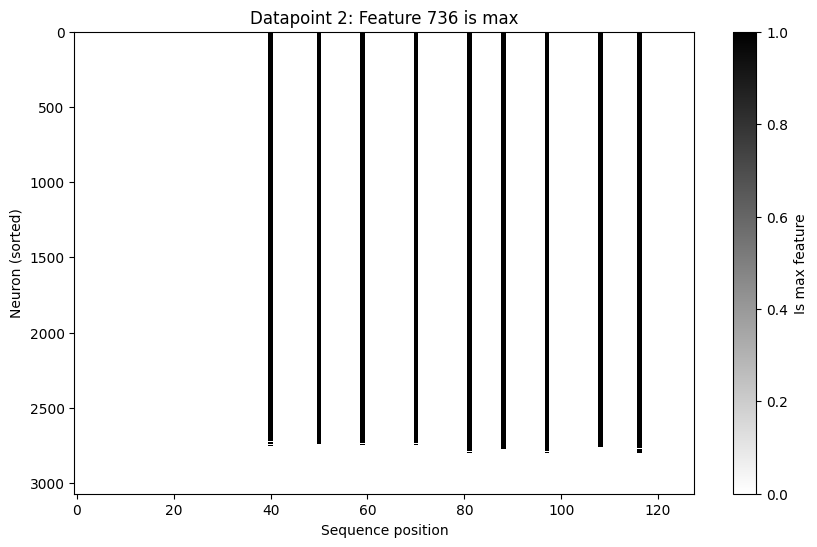

/var/folders/l4/n2lzrqrj6mvd68trptwvv27m0000gn/T/ipykernel_20271/3857898304.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('nipy_spectral', num_feats)


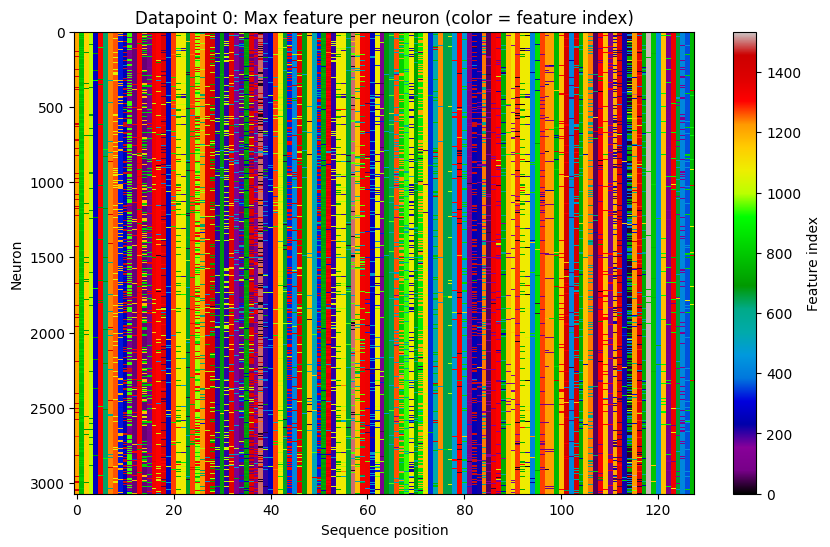

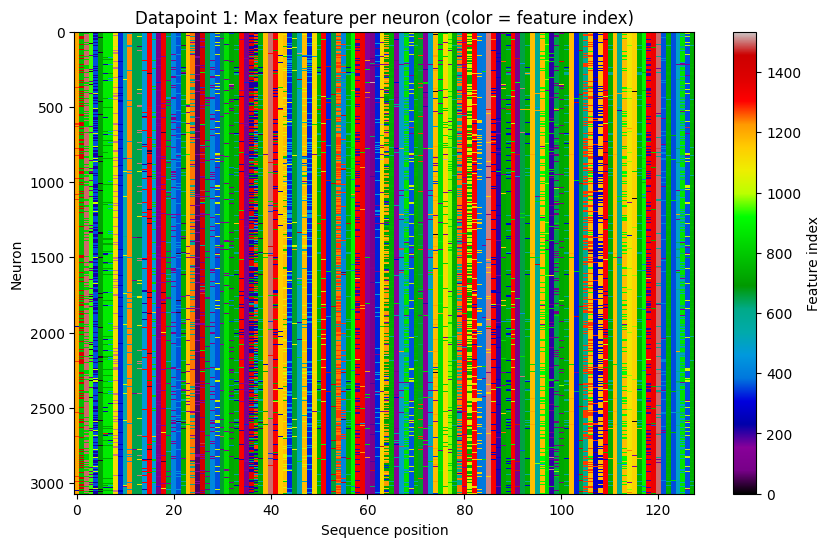

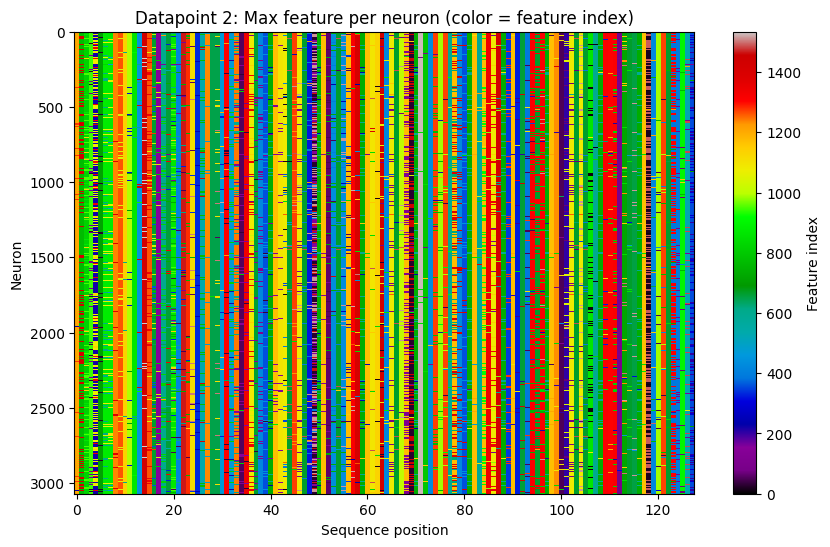

In [7]:
layer = 2
num_datapoints = 10
datapoints = dataset[0:num_datapoints]['text']

max_features = torch.zeros(num_datapoints, 128, llm.blocks[layer].mlp.W_in.shape[1])

W_in = llm.blocks[layer].mlp.W_in
W_out = llm.blocks[layer].mlp.W_out
W_dec = crosscoder.W_dec_HXD[:,0,hookpoints.index(f"blocks.{layer}.ln2.hook_normalized"),:]
W_dec_W_in = W_dec @ W_in

for i, datapoint in enumerate(datapoints):
	activations_SMPD = get_llm_activations_SMPD(datapoint, llm)
	feature_activations_SH = crosscoder._encode_BH(activations_SMPD)
	for s in range(128):
		active_features = torch.where(feature_activations_SH[s, :] != 0.0)[0]
		per_feature_preactivations_HA = W_dec_W_in[active_features, :] * feature_activations_SH[s, active_features, None]
		per_feature_abs_preactivations_HA = per_feature_preactivations_HA.abs()
		datapoint_max_features_A = active_features[torch.argmax(per_feature_abs_preactivations_HA, dim=0)]
		max_features[i, s, :] = datapoint_max_features_A

# gather unique max-feature indices sorted by how frequently they occur
flat_max = max_features.view(-1).long()
unique_feats, counts = torch.unique(flat_max, return_counts=True)
# sort by descending frequency
counts_sorted, order = torch.sort(counts, descending=True)
sorted_feats = unique_feats[order].tolist()
counts_sorted = counts_sorted.tolist()

###################
# First plot when the most common max feature is max, after sorting neurons by how often this feature is max

feature = sorted_feats[0]
# Compute how often each neuron picks feature as its max
mask = (max_features == feature)                    # shape: (num_datapoints, seq_len, num_neurons)
flat_mask = mask.view(-1, mask.shape[2])           # shape: (num_datapoints*seq_len, num_neurons)
counts_per_neuron = flat_mask.sum(dim=0)           # shape: (num_neurons,)
# Sort neurons by descending count
counts_sorted, neuron_order = torch.sort(counts_per_neuron, descending=True)
# Convert to Python lists for printing
sorted_neurons = neuron_order.tolist()
counts_sorted = counts_sorted.tolist()

import matplotlib.pyplot as plt

datapoints_to_show = 3
for idx in range(datapoints_to_show):
	# Get boolean mask for this datapoint: shape (seq_len, num_neurons)
	mask_dp = mask[idx]
	# Reorder neurons according to the sorted_neurons list
	mask_sorted = mask_dp[:, sorted_neurons]
	# Plot as an image: x-axis = sequence pos, y-axis = neuron index (sorted)
	plt.figure(figsize=(10, 6))
	plt.imshow(mask_sorted.T, aspect='auto', cmap='binary', interpolation='nearest')
	plt.xlabel('Sequence position')
	plt.ylabel('Neuron (sorted)')
	plt.title(f'Datapoint {idx}: Feature {feature} is max')
	plt.colorbar(label='Is max feature')
	plt.show()

##################
# Now plot max feature for each neuron across sequence with distinct colours for each feature

num_feats = int(max_features.max().item()) + 1
# Use a discrete colormap with one color per feature
cmap = plt.cm.get_cmap('nipy_spectral', num_feats)

for idx in range(datapoints_to_show):
	# Extract the max-feature indices for this datapoint: shape (seq_len, num_neurons)
	mf = max_features[idx].cpu().long().numpy()
	plt.figure(figsize=(10, 6))
	im = plt.imshow(
		mf.T,
		aspect='auto',
		cmap=cmap,
		vmin=0,
		vmax=num_feats - 1,
		interpolation='nearest'
	)
	plt.xlabel('Sequence position')
	plt.ylabel('Neuron')
	plt.title(f'Datapoint {idx}: Max feature per neuron (color = feature index)')
	plt.colorbar(im, label='Feature index')
	plt.show()


In [8]:
from sleepers.analysis.ft_analysis_util import display_feature_activation_visualization

example_texts = [dataset[i]["text"] for i in range(100)]
example_llm_activations = [get_llm_activations_SMPD(text, llm) for text in example_texts]
example_activations = [crosscoder._encode_BH(activations) for activations in example_llm_activations]

# display up to number_examples stories with the relevant feature active, out of the first 100 stories in the dataset
def display_feature_activations_where_active(feature_index, number_examples=2):
	texts_idxs = [i for i, acts in enumerate(example_activations) if acts[:, feature_index].sum() > 0]
	texts_idxs = texts_idxs[:number_examples]
	if len(texts_idxs) > 0:
		print(texts_idxs)
		display(display_feature_activation_visualization(
			tokenizer,
			[example_texts[i] for i in texts_idxs],
			[example_activations[i] for i in texts_idxs],
			feature_index=feature_index))
	else:
		print("No examples found with non-zero activation")

In [9]:
num_features = crosscoder.W_dec_HXD.shape[0]

# Return an array of feature interactions averaged across neurons, dimensions (sequence position, num crosscoder features, num crosscoder features)
def feature_interactions_mlp_sequence(input, layer):
	W_in = llm.blocks[layer].mlp.W_in
	W_out = llm.blocks[layer].mlp.W_out
	W_dec = crosscoder.W_dec_HXD[:,0,hookpoints.index(f"blocks.{layer}.ln2.hook_normalized"),:]
	W_dec_W_in = W_dec @ W_in
	
	normalisation = W_out.norm(dim=1)

	tokens = torch.tensor(tokenizer.encode(input)[0:128])
	feature_interactions = np.zeros((len(tokens), num_features, num_features))

	activations_SMLD = get_llm_activations_SMPD(input, llm)
	feature_activations_SH = crosscoder._encode_BH(activations_SMLD)
	for s in range(128):
		active_features = torch.where(feature_activations_SH[s, :] != 0.0)[0]
		per_feature_preactivations_HA = W_dec_W_in[active_features, :] * feature_activations_SH[s, active_features, None]
		per_feature_abs_preactivations_HA = per_feature_preactivations_HA.abs()
		max_features = active_features[torch.argmax(per_feature_abs_preactivations_HA, dim=0)]
		rows = max_features.cpu().numpy()
		cols = active_features.cpu().numpy()
		# use np.ix_ to broadcast the two 1d index arrays into a 2d block
		interaction_HA = per_feature_abs_preactivations_HA*normalisation[None, :]
		feature_interactions[s][np.ix_(rows, cols)] += interaction_HA.T.cpu().numpy()
		feature_interactions[s][rows, rows] = 0
	return feature_interactions

# Have factored out feature_interactions_mlp_sequence to avoid repeating code but significantly faster
# if you inline it as commented out, or could probably cache some things

# Return an array of feature interactions averaged across neurons and sequence positions, dimensions (num crosscoder features, num crosscoder features)
def feature_interactions_mlp(layer, num_datapoints):
	# W_in = llm.blocks[layer].mlp.W_in
	# W_out = llm.blocks[layer].mlp.W_out
	# W_dec = crosscoder.W_dec_HXD[:,0,hookpoints.index(f"blocks.{layer}.ln2.hook_normalized"),:]
	# W_dec_W_in = W_dec @ W_in
	
	# normalisation = W_out.norm(dim=1)
	
	feature_interactions = np.zeros((num_features, num_features))
	for i in range(num_datapoints):
		input = dataset[i]["text"]
		feature_interactions_sequence = feature_interactions_mlp_sequence(input, layer)
		feature_interactions += feature_interactions_sequence.sum(axis=0)
		# activations_SMLD = get_llm_activations_SMPD(input, llm)
		# feature_activations_SH = crosscoder._encode_BH(activations_SMLD)
		# for s in range(128):
		#     active_features = torch.where(feature_activations_SH[s, :] != 0.0)[0]
		#     per_feature_preactivations_HA = W_dec_W_in[active_features, :] * feature_activations_SH[s, active_features, None]
		#     per_feature_abs_preactivations_HA = per_feature_preactivations_HA.abs()
		#     max_features = active_features[torch.argmax(per_feature_abs_preactivations_HA, dim=0)]
		#     rows = max_features.cpu().numpy()
		#     cols = active_features.cpu().numpy()
		#     # use np.ix_ to broadcast the two 1d index arrays into a 2d block
		#     interaction_HA = per_feature_abs_preactivations_HA*normalisation[None, :]
		#     feature_interactions[np.ix_(rows, cols)] += interaction_HA.T.cpu().numpy()
		#     feature_interactions[rows, rows] = 0
	
	feature_interactions = feature_interactions / (num_datapoints * 128)
	return feature_interactions

In [ ]:
feature_interactions = feature_interactions_mlp(1, 20)

# Print the top-k largest entries in feature_interactions
k = 10
flat = feature_interactions.flatten()
# get indices of the top k values
topk_idx = np.argsort(flat)[::-1][:k]
rows, cols = np.unravel_index(topk_idx, feature_interactions.shape)
print(f"Top {k} feature interactions (feature_i, feature_j, value):")
for r, c, idx_flat in zip(rows, cols, topk_idx):
	val = flat[idx_flat]
	print(f"Feature {r} & Feature {c}: {val:.6f}")

Top 10 feature interactions (feature_i, feature_j, value):
Feature 996 & Feature 1024: 0.001732
Feature 25 & Feature 944: 0.001474
Feature 199 & Feature 1024: 0.001254
Feature 1047 & Feature 1507: 0.000990
Feature 1019 & Feature 823: 0.000896
Feature 989 & Feature 502: 0.000822
Feature 772 & Feature 533: 0.000771
Feature 750 & Feature 578: 0.000733
Feature 8 & Feature 867: 0.000731
Feature 968 & Feature 1114: 0.000713


996, 1024 - name features

25, commas in Words; 994, first comma in Words/Summary

199, 1024 - name features

1019, 823 - name features

1047, 1507 - "their" features

In [ ]:
feature_interactions = feature_interactions_mlp(2, 20)

# Print the top-k largest entries in feature_interactions
k = 10
flat = feature_interactions.flatten()
# get indices of the top k values
topk_idx = np.argsort(flat)[::-1][:k]
rows, cols = np.unravel_index(topk_idx, feature_interactions.shape)
print(f"Top {k} feature interactions (feature_i, feature_j, value):")
for r, c, idx_flat in zip(rows, cols, topk_idx):
	val = flat[idx_flat]
	print(f"Feature {r} & Feature {c}: {val:.6f}")

Top 10 feature interactions (feature_i, feature_j, value):
Feature 578 & Feature 736: 0.053907
Feature 736 & Feature 578: 0.003516
Feature 578 & Feature 47: 0.002779
Feature 578 & Feature 240: 0.001824
Feature 736 & Feature 240: 0.001619
Feature 736 & Feature 750: 0.001524
Feature 463 & Feature 88: 0.001510
Feature 578 & Feature 750: 0.001305
Feature 989 & Feature 502: 0.001301
Feature 420 & Feature 120: 0.001267


Mostly various full stop features

1462 unclear, 533 fires on Story tag

In [12]:
# TODO baseline weighted by layer?

def baseline_feature_interactions(num_datapoints):
	num_features = crosscoder.W_dec_HXD.shape[0]
	
	feature_interactions = np.zeros((num_features, num_features))
	for i in range(num_datapoints):
		input = dataset[i]["text"]
		activations_SMLD = get_llm_activations_SMPD(input, llm)
		feature_activations_SH = crosscoder._encode_BH(activations_SMLD)
		for s in range(128):
			active_features = torch.where(feature_activations_SH[s, :] != 0.0)[0]
			feature_square = feature_activations_SH[s, active_features, None] * feature_activations_SH[s, None, active_features]
			feature_interactions[np.ix_(active_features, active_features)] += feature_square.cpu().numpy()
			feature_interactions[active_features, active_features] = 0
	
	feature_interactions = feature_interactions / (num_datapoints * 128)
	return feature_interactions

In [31]:
from IPython.display import HTML
from sleepers.analysis.ft_analysis_util import display_text_with_highlighting
from sleepers.analysis.analysis_utils import get_activations

def example_interactions_for_layer(layer, number_stories=50):
	example_texts = [dataset[i]["text"] for i in range(number_stories)]
	example_interactions = [feature_interactions_mlp_sequence(input, layer) for input in example_texts]
	return example_interactions

def display_feature_interactions_where_active(example_interactions, feature_1, feature_2, number_examples=2):
	texts_idxs = [i for i, ints in enumerate(example_interactions) if ints[:, feature_1, feature_2].sum() > 0]
	texts_idxs = texts_idxs[:number_examples]
	if len(texts_idxs) > 0:
		print(texts_idxs)
		html_vis = []
		for idx in texts_idxs:
			tokens = torch.tensor(tokenizer.encode(example_texts[idx])[0:128])
			values = example_interactions[idx][:, feature_1, feature_2]
			html = display_text_with_highlighting(tokens, tokenizer, values, transparent_test=lambda x: x == 0)
			html_vis.append(html.data)
			block=1
			feat_1_vals=get_activations(example_texts[idx], llm, crosscoder)[0][:,feature_1].detach().cpu().numpy()
			html_feat_1=display_text_with_highlighting(tokens, tokenizer, feat_1_vals, transparent_test=lambda x: x == 0)
			html_vis.append(html_feat_1.data)
			feat_2_vals=get_activations(example_texts[idx], llm, crosscoder)[0][:,feature_2].detach().cpu().numpy()
			html_feat_2=display_text_with_highlighting(tokens, tokenizer, feat_2_vals, transparent_test=lambda x: x == 0)
			html_vis.append(html_feat_2.data)
		combined_html = f"""
		<div style='display: flex; flex-direction: column; gap: 0px;'>
			<h3>Feature {feature_1} & Feature {feature_2} Interaction Visualization</h3>
			{"".join(html_vis)}
		</div>
		"""
		return HTML(combined_html)
	else:
		print("No examples found with non-zero interaction")

In [14]:
# cache feature interactions for 50 example stories
example_interactions = example_interactions_for_layer(1, number_stories=50)

In [34]:
# display feature interactions for features 25 and 994
display_feature_interactions_where_active(example_interactions, 996, 1024, number_examples=1)

[1]


In [17]:
feature_interactions = baseline_feature_interactions(20)

# Print the top-k largest entries in feature_interactions
k = 10
flat = feature_interactions.flatten()
# get indices of the top k values
topk_idx = np.argsort(flat)[::-1][:k]
rows, cols = np.unravel_index(topk_idx, feature_interactions.shape)
print(f"Top {k} feature interactions (feature_i, feature_j, value):")
for r, c, idx_flat in zip(rows, cols, topk_idx):
	val = flat[idx_flat]
	print(f"Feature {r} & Feature {c}: {val:.6f}")

Top 10 feature interactions (feature_i, feature_j, value):
Feature 1276 & Feature 233: 62.112430
Feature 233 & Feature 1276: 62.112430
Feature 1276 & Feature 847: 37.086173
Feature 847 & Feature 1276: 37.086173
Feature 736 & Feature 578: 32.150850
Feature 578 & Feature 736: 32.150850
Feature 665 & Feature 701: 29.291891
Feature 701 & Feature 665: 29.291891
Feature 1161 & Feature 665: 26.713403
Feature 665 & Feature 1161: 26.713403


Broadly activating features

Full stop features

And features

In [27]:
display_feature_activations_where_active(502, 5)

[0, 3, 4, 5, 6]


---------------------

Dmitry's code below here

In [32]:
from model_diffing.utils import calculate_reconstruction_loss
from sleepers.scripts.utils import calculate_fvu_X

hookpoints = [
	"blocks.0.hook_resid_pre",
	"blocks.0.ln1.hook_normalized", 
	"blocks.0.hook_resid_mid",
	"blocks.0.ln2.hook_normalized",
	"blocks.1.hook_resid_pre", 
	"blocks.1.ln1.hook_normalized",
	"blocks.1.hook_resid_mid",
	"blocks.1.ln2.hook_normalized",
	"blocks.2.hook_resid_pre",
	"blocks.2.ln1.hook_normalized",
	"blocks.2.hook_resid_mid",
	"blocks.2.ln2.hook_normalized",
	"blocks.3.hook_resid_pre",
	"blocks.3.ln1.hook_normalized",
	"blocks.3.hook_resid_mid",
	"blocks.3.ln2.hook_normalized",
	"blocks.3.hook_resid_post"
]

def get_activations(input: str, model=llm, crosscoder=crosscoder):
	tokens = torch.tensor(tokenizer.encode(input)[0:128])
	_, cache = model.run_with_cache(tokens.unsqueeze(0), names_filter=hookpoints)
	activations_BSLD = torch.stack([cache[name] for name in hookpoints], dim=2)
	activations_BSMLD = torch.unsqueeze(activations_BSLD, dim=2)
	
	activations_SMLD = rearrange(activations_BSMLD, "b s m l d -> (b s) m l d")
	return activations_SMLD

input = dataset[6]["text"]

activations_SMLD=get_activations(input, llm, crosscoder)
feature_activations_SH = crosscoder._encode_BH(activations_SMLD)
reconstructed_acts_SMLD = crosscoder._decode_BXD(feature_activations_SH)

rec_loss = calculate_reconstruction_loss(activations_SMLD[:,0,:,:], reconstructed_acts_SMLD[:,0,:,:])
print(f'rec_loss: {rec_loss}')
print(f'rec_loss percent: {100*rec_loss/(calculate_reconstruction_loss(activations_SMLD[:,0,:,:],0))}%')

# get the unexplained variance
unexplained_variance = []
for p in range(activations_SMLD.shape[2]):
	unexplained_variance.append(calculate_fvu_X(activations_SMLD[:,:,p,:], reconstructed_acts_SMLD[:,:,p,:]).cpu().detach().numpy())
mean_unexplained_variance = np.mean(np.array(unexplained_variance))

print(f'mean unexplained variance: {mean_unexplained_variance}')

rec_loss: 2489.7646484375
rec_loss percent: 23.315959930419922%
mean unexplained variance: 0.408750057220459


OK, so now let's run the heatmaps for BatchTopK

In [25]:
from transformers.activations import NewGELUActivation, FastGELUActivation
from model_diffing.utils import calculate_reconstruction_loss,l2_norm
from sleepers.scripts.utils import calculate_fvu_X

def mlp_reconstruction(cache:dict,block:int,llm:object):
	print(f'Activation function is: {llm.blocks[0].mlp.act_fn}')
	act_fn=llm.blocks[0].mlp.act_fn
	raw_acts_ln=cache[f"blocks.{block}.ln2.hook_normalized"]
	raw_acts_ln=raw_acts_ln[0,:,:]

	raw_acts_mid=cache["blocks.0.hook_resid_mid"]
	raw_acts_mid=raw_acts_mid[0,:,:]

	raw_acts_post=cache["blocks.0.hook_resid_post"]
	raw_acts_post=raw_acts_post[0,:,:]


	W_in=llm.blocks[block].mlp.W_in
	b_in=llm.blocks[block].mlp.b_in
	W_out=llm.blocks[block].mlp.W_out
	b_out=llm.blocks[block].mlp.b_out


	preacts = raw_acts_ln @ W_in + b_in

	postacts = act_fn(preacts)
	postacts_relu=nn.ReLU()(preacts)
	postacts_gelu=NewGELUActivation()(preacts)

	ffn_output = postacts @ W_out + b_out
	ffn_output_relu=postacts_relu @ W_out + b_out
	ffn_output_gelu=postacts_gelu @ W_out + b_out

	reconstructed_post=raw_acts_mid+ffn_output
	reconstructed_post_relu=raw_acts_mid+ffn_output_relu
	reconstructed_post_gelu=raw_acts_mid+ffn_output_gelu

	diff=reconstructed_post-raw_acts_post
	diff_relu=reconstructed_post_relu-raw_acts_post
	diff_gelu=reconstructed_post_gelu-raw_acts_post
	print(f'diff sum: {100*diff.abs().sum()/raw_acts_post.abs().sum()}%')
	print(f'diff_relu sum: {100*diff_relu.abs().sum()/raw_acts_post.abs().sum()}%')
	print(f'diff_gelu sum: {100*diff_gelu.abs().sum()/raw_acts_post.abs().sum()}%')


def get_preacts_nocontract(enc_acts:torch.Tensor, W_dec_HMLD:torch.Tensor, b_dec_MLD:torch.Tensor,llm:object,block:int=0, bias=True):
	"""
	Get the preacts without contracting the feature dimension
	"""
	W_in = llm.blocks[block].mlp.W_in
	b_in = llm.blocks[block].mlp.b_in
	
	#Note that you have to divide by the number of features to get the correct bias
	if bias:
		bias_factor = 1
	else:
		bias_factor = 0
	hidden_dim = enc_acts.shape[1]
	dec_nocontract = (enc_acts[:,:,None] * W_dec_HMLD[None,:,0,4*block+3,:]) + bias_factor*b_dec_MLD[0,4*block+3,:].unsqueeze(0)/hidden_dim
		

	#OK so decoding is correct, then let's push through the mlp
	pre_acts=einsum(W_in, dec_nocontract, "d_model d_mlp, batch hidden d_model -> batch hidden d_mlp")
	pre_acts += bias_factor*b_in/hidden_dim
	pre_acts = rearrange(pre_acts, 'batch hidden d_mlp -> batch d_mlp hidden')
	
	return pre_acts

def get_weight_features(W_in:torch.Tensor, b_in:torch.Tensor, W_dec_HMLD:torch.Tensor, b_dec_MLD:torch.Tensor, block:int=0):
	"""
	Get W(W_f+B_D), without contracting the feature dimension
	"""

	hidden_dim = W_dec_HMLD.shape[0]
	
	W_dec_HD = W_dec_HMLD[:,0,3*block+1,:]
	b_dec_D = b_dec_MLD[0,3*block+1,:]
	
	b_dec_DH = torch.zeros_like(W_dec_HD)
	b_dec_DH[:,np.arange(W_dec_HD.shape[1])] = b_dec_D/hidden_dim
	b2 = b_dec_MLD[0,3*block+1,:].unsqueeze(0)/hidden_dim
	
	
	
	non_contract_tensor = einsum(W_in, (W_dec_HMLD[:,0,3*block+1,:] + b_dec_MLD[0,3*block+1,:].unsqueeze(0)/hidden_dim), "d_model d_mlp, hidden d_model -> d_mlp hidden")
	non_contract_tensor += b_in[:,None]/hidden_dim

	non_contract_tensor_W = einsum(W_in, W_dec_HD, "d_model d_mlp, hidden d_model -> d_mlp hidden")
	non_contract_tensor_W += b_in[:,None]/hidden_dim

	non_contract_tensor_b = einsum(W_in, b_dec_DH, "d_model d_mlp, hidden d_model -> d_mlp hidden")
	#Don't need this because you only add in the bias once
	#non_contract_tensor_b += b_in[:,None]/non_contract_tensor_b.shape[-1]

	#print(f'total same: {100*torch.sum(non_contract_tensor-non_contract_tensor_W-non_contract_tensor_b)/torch.sum(non_contract_tensor)}%')

	
	return non_contract_tensor, non_contract_tensor_W, non_contract_tensor_b

def get_preacts_ind(enc_acts:torch.Tensor, W_in:torch.Tensor, b_in:torch.Tensor, W_dec_HMLD:torch.Tensor, b_dec_MLD:torch.Tensor, block:int):
		
	hidden_dim = W_dec_HMLD.shape[0]
	W_dec_HD = W_dec_HMLD[:,0,4*block+3,:]
	b_dec_D = b_dec_MLD[0,4*block+3,:]

	print(f'enc_acts.shape: {enc_acts[...,None].shape}')
	print(f'W_dec_HD.shape: {W_dec_HD[None,:,:].shape}')
	

	enc_BHD_W = einsum(enc_acts[...,None], W_dec_HD[None,:,:], "batch hidden one, one hidden d_model -> batch d_model hidden")
	enc_BHD_b = b_dec_D[None,:,None]/hidden_dim
	p_BNH = einsum(W_in, enc_BHD_W+enc_BHD_b, "d_model d_mlp, batch d_model hidden -> batch d_mlp hidden")
	p_BNH += b_in[:,None]/hidden_dim

	data_ind_w = einsum(W_in, W_dec_HD, "d_model d_mlp, hidden d_model -> d_mlp hidden")

	b_dec_DH = torch.zeros_like(W_dec_HD)
	b_dec_DH[:,np.arange(W_dec_HD.shape[1])] = b_dec_D/hidden_dim
	data_ind_b = einsum(W_in, b_dec_DH, "d_model d_mlp, hidden d_model -> d_mlp hidden")
	data_ind_b += b_in[:,None]/hidden_dim

	return enc_acts[:,None,:]*data_ind_w+data_ind_b, data_ind_w, data_ind_b


def check_data_decomposition(block:int,llm:object,enc_acts:torch.Tensor,W_dec_HMLD:torch.Tensor, b_dec_MLD:torch.Tensor):
	#block = 3
	W_in = llm.blocks[block].mlp.W_in
	W_out = llm.blocks[block].mlp.W_out
	b_in = llm.blocks[block].mlp.b_in
	b_out = llm.blocks[block].mlp.b_out


	preacts_BNH = get_preacts_nocontract(enc_acts,W_dec_HMLD, b_dec_MLD, W_in, b_in,bias=True,block=block)
	p_BNH, data_ind_w, data_ind_b = get_preacts_ind(enc_acts, W_in, b_in, W_dec_HMLD, b_dec_MLD, block)

	print(f'preacts_BNH equal to p_BNH: {100*torch.sum(preacts_BNH-p_BNH)/torch.sum(p_BNH)}% error')



Need to input parameters to look through

In [ ]:
block=0
input = dataset[4]["text"]
xc_train_names=[hook for block_ind in range(4) for hook in [
	f"blocks.{block_ind}.hook_resid_pre", 
	f"blocks.{block_ind}.ln1.hook_normalized", 
	f"blocks.{block_ind}.hook_resid_mid", 
	f"blocks.{block_ind}.ln2.hook_normalized"
]]
xc_train_names.append(f"blocks.{block}.hook_resid_post")


print(xc_train_names)

print(len(xc_train_names))

xc_train_names_old=[hook for block_ind in range(4) for hook in [
	f"blocks.{block_ind}.hook_resid_pre", 
	f"blocks.{block_ind}.hook_resid_mid", 
	f"blocks.{block_ind}.hook_resid_post"
]]

print(f"input: \n {input}")


used_names=xc_train_names

In [ ]:
import yaml
from pathlib import Path

def load_yaml_config(file_path):
	"""
	Load configuration from a YAML file.
	
	Args:
		file_path (str or Path): Path to the YAML configuration file
	
	Returns:
		dict: The loaded configuration as a dictionary
	"""
	file_path = Path(file_path)
	if not file_path.exists():
		raise FileNotFoundError(f"Config file not found: {file_path}")
	
	with open(file_path, 'r') as f:
		config = yaml.safe_load(f)
	
	print(f"Loaded configuration from {file_path}")
	return config


config = load_yaml_config("/Users/dmitrymanning-coe/Documents/Research/compact_proofs/code/post_fork/crosscoders-feature-interactions/sleepers/sleepers/scripts/train_topk_sleeper/test.yaml")

print(config["hookpoints"])

used_names=config["hookpoints"]

In [ ]:
	

# _, cache = llm.run_with_cache(sequence_BS, names_filter=used_names, stop_at_layer=self._layer_to_stop_at)
# # cache[name] is shape BSD, so stacking on dim 2 = BSPD
# activations_BSPD = torch.stack([cache[name] for name in self._hookpoints], dim=2)  # adds hookpoint dim (P)
		

# tokens = torch.tensor(tokenizer.encode(input)[0:128])
# _, cache = llm.run_with_cache(tokens.unsqueeze(0), names_filter=used_names)

# activations_BSPD = torch.stack([cache[name] for name in used_names], dim=2)
# print(f'activations_BSPD.shape: {activations_BSPD.shape}')

Let's see if we can write a patched loss function

Let's try and qucickly look at cdf heatmaps

In [45]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def get_heatmap_NH(tensor_NH:torch.Tensor, abs=True):
	
	#values_NH,indices_NH=torch.sort(tensor_NH.abs().sum(dim=0),dim=-1,descending=True)
	values_NH, indices_NH = torch.sort(tensor_NH, dim=-1, descending=True)
	if abs:
		cumsum_values_NH = torch.cumsum(values_NH, dim=-1)
	else:
		cumsum_values_NH = torch.cumsum(values_NH, dim=-1)
	
	cumsum_abs_ratio = cumsum_values_NH/cumsum_values_NH[:,-1].unsqueeze(-1)
	cumsum_signed_ratio = torch.cumsum(values_NH, dim=-1)/torch.sum(values_NH, dim=-1).unsqueeze(-1)
	print(f'cumsum abs ratio shape {cumsum_abs_ratio.shape}')
	
	#To sort the neurons by which is the most peaked
	n_vals, n_idx = torch.sort(cumsum_abs_ratio[:,0], dim=0, descending=True)
	cumsum_abs_ratio = cumsum_abs_ratio[n_idx,:]
	
	return cumsum_abs_ratio

def add_heatmap(fig:go.Figure,data_tensor_NH:torch.Tensor,row:int,col:int):
	fixed_colorscale=[[0, 'blue'],[0.5,'white'],[0.51,'green'],[0.52,'white'], [0.9, 'red'], [1, 'black']]
	if row==1 and col==1:
		show_scale=True
	else:
		show_scale=False
	fig.add_trace(
		go.Heatmap(z=data_tensor_NH,x=np.arange(data_tensor_NH.shape[1]),y=np.arange(data_tensor_NH.shape[0]),
			colorscale=fixed_colorscale, # Adjust scale to make red more prominent
			colorbar=dict(title='Color Scale'),
			showscale=show_scale
		),row=row, col=col
	)
	fig.update_xaxes(title_text="Feature")
	fig.update_yaxes(title_text="Neuron")


def data_decomposition_heatmap(enc_acts:torch.Tensor,llm:object,block:int=0):
	
	W_in = llm.blocks[block].mlp.W_in
	b_in = llm.blocks[block].mlp.b_in
	#preacts_BNH = get_preacts_nocontract(enc_acts,W_dec_HMLD, b_dec_MLD, W_in, b_in,bias=True,block=block)
	p_BNH, data_ind_w, data_ind_b = get_preacts_ind(enc_acts, W_in, b_in, W_dec_HMLD, b_dec_MLD, block)
	enc_acts_tensor = enc_acts.abs()

	preacts_NH = p_BNH.abs().sum(dim=0)
	enc_acts_hm = get_heatmap_NH(enc_acts_tensor)
	heatmap_whole = get_heatmap_NH(preacts_NH)
	heatmap_data_ind = get_heatmap_NH(data_ind_w.abs())

	sep_fig=make_subplots(rows=1,cols=3,subplot_titles=['Encoding distribution alpha','Data-independent distribution (W^in W^dec)','Feature distribution'])

	add_heatmap(sep_fig,enc_acts_hm,row=1,col=1)
	add_heatmap(sep_fig,heatmap_data_ind,row=1,col=2)
	add_heatmap(sep_fig,heatmap_whole,row=1,col=3)

	sep_fig.update_xaxes(range=[0,50],row=1,col=1)
	sep_fig.update_xaxes(range=[0,100],row=1,col=3)
	sep_fig.update_yaxes(title_text="Token",col=1)
	return sep_fig

def block_heatmaps(enc_acts:torch.Tensor,llm:object):
	fig=make_subplots(rows=2,cols=4)
	for block in range(4):
		W_in = llm.blocks[block].mlp.W_in
		b_in = llm.blocks[block].mlp.b_in
		preacts_BNH = get_preacts_nocontract(enc_acts,W_dec_HMLD, b_dec_MLD, W_in, b_in,bias=True,block=block)
		preacts_NH_sum = preacts_BNH.abs().sum(dim=0)
		preacts_NH_std = preacts_BNH.std(dim=0)

		add_heatmap(fig,get_heatmap_NH(preacts_NH_sum),row=1,col=1+block)
		add_heatmap(fig,get_heatmap_NH(preacts_NH_std),row=2,col=1+block)
	return fig

In [ ]:


W_dec_HMLD = crosscoder.W_dec_HXD
b_dec_MLD = crosscoder.b_dec_XD

def mlp_reconstruction_features(enc_acts:torch.Tensor,raw_acts:torch.Tensor,W_dec_HXD:torch.Tensor,b_dec_MXD:torch.Tensor,llm:object,block:int=0):
	W_in = llm.blocks[block].mlp.W_in
	b_in = llm.blocks[block].mlp.b_in
	W_out = llm.blocks[block].mlp.W_out
	b_out = llm.blocks[block].mlp.b_out

	post_mlp_acts=dec_acts[:,0,4*block+4,:]
	resid_acts=dec_acts[:,0,4*block+2,:]
	

	p_BNH, data_ind_w, data_ind_b = get_preacts_ind(enc_acts, W_in, b_in, W_dec_HXD, b_dec_MXD, block)
	p_BNH_summed=p_BNH.sum(dim=-1)
	p_BNH_summed=NewGELUActivation()(p_BNH_summed)
	post_mlp=p_BNH_summed@W_out+b_out
	rec_post=resid_acts+post_mlp

	rec_loss=calculate_reconstruction_loss(rec_post,post_mlp_acts)
	rel_rec_loss=rec_loss/(calculate_reconstruction_loss(post_mlp_acts,0))

	return rel_rec_loss

#Let's get decoder rel. reconstruction loss for each hookpoint

print(f'raw_acts.shape: {raw_acts.shape}')
print(f'dec_acts.shape: {dec_acts.shape}')

def hookpoints_losses(raw_acts:torch.Tensor,dec_acts:torch.Tensor,hookpoints:List[str]):
	#Want to calculate the rel. reconstruction, abs reconstruction, and unexplained variance for each hookpoint
	rec_losses=[]
	rel_rec_losses=[]
	unexplained_variances=[]

	for hp_ind, hookpoint in enumerate(hookpoints):
		rec_loss=calculate_reconstruction_loss(dec_acts[:,0,hp_ind,:],raw_acts[:,0,hp_ind,:])
		rel_rec_loss=rec_loss/(calculate_reconstruction_loss(raw_acts[:,0,hp_ind,:],0))
		unexplained_variance=calculate_fvu_X(raw_acts[:,0,hp_ind,:],dec_acts[:,0,hp_ind,:])
		rec_losses.append(rec_loss)
		rel_rec_losses.append(rel_rec_loss)
		unexplained_variances.append(unexplained_variance)

	return rec_losses,rel_rec_losses,unexplained_variances


#test_losses=hookpoints_losses(raw_acts,dec_acts,used_names)

def plot_losses(rec_losses:List[float],rel_rec_losses:List[float],unexplained_variances:List[float],used_names:List[str]):
	fig=make_subplots(rows=1,cols=3,subplot_titles=['Reconstruction Loss','Relative Reconstruction Loss','Unexplained Variance'])

	for hp_ind, hookpoint in enumerate(used_names):
		fig.add_trace(go.Scatter(x=np.arange(len(rec_losses)),y=rec_losses,name=f'{hookpoint} rec loss',showlegend=False),row=1,col=1)
		fig.add_trace(go.Scatter(x=np.arange(len(rel_rec_losses)),y=rel_rec_losses,name=f'{hookpoint} rel rec loss',showlegend=False),row=1,col=2)
		fig.add_trace(go.Scatter(x=np.arange(len(unexplained_variances)),y=unexplained_variances,name=f'{hookpoint} unexplained variance',showlegend=False),row=1,col=3)

		fig.update_xaxes(title_text="Hookpoint")
		fig.update_yaxes(title_text="Reconstruction Loss",col=1)
		fig.update_yaxes(title_text="Relative Reconstruction Loss",col=2)
		fig.update_yaxes(title_text="Unexplained Variance",col=3)

		return fig

#plot_losses(*test_losses,used_names).show()


#test_enc=get_heatmap_NH(enc_acts.abs(),abs=True)
# fig=make_subplots(rows=1,cols=1)
# add_heatmap(fig,test_enc,row=1,col=1)
# fig.update_xaxes(title_text="Feature",range=[0,50])
# fig.update_yaxes(title_text="Token")
# fig.show()




In [ ]:
test_enc=get_heatmap_NH(enc_acts.abs(),abs=True)
#p_BNH, data_ind_w, data_ind_b = get_preacts_ind(enc_acts, W_in, b_in, W_dec_HXD, b_dec_MXD, block)
#data_decomposition_heatmap(enc_acts,llm,0)
# fig=make_subplots(rows=1,cols=1)
# add_heatmap(fig,test_enc,row=1,col=1)
# fig.update_xaxes(title_text="Feature",range=[0,50])
# fig.update_yaxes(title_text="Token")
# fig.show()

In [ ]:
from sleepers.scripts.utils import calculate_fvu_X

#raw_acts=torch.stack([cache[name] for name in used_names],dim=0)
#raw_acts=rearrange(raw_acts,"layer model batch d_model -> batch model layer d_model")

raw_acts=activations_BSPD
raw_acts=rearrange(raw_acts,"model batch layer d_model -> batch model layer d_model")

print(f'raw_acts.shape: {raw_acts.shape}')

encoded_acts=crosscoder._encode_BH(raw_acts)
#decoded_acts=crosscoder._decode_BXD(encoded_acts)
decoded_acts=crosscoder._forward(raw_acts).output_BXD

print(f'encoded_acts.shape: {encoded_acts.shape}')
print(f'decoded_acts.shape: {decoded_acts.shape}')

unexplained_variance = []
for p in range(raw_acts.shape[2]):
	unexplained_variance.append(calculate_fvu_X(raw_acts[:,:,p,:], decoded_acts[:,:,p,:]).cpu().detach().numpy())
mean_unexplained_variance = np.mean(np.array(unexplained_variance))

print(f'mean unexplained variance: {mean_unexplained_variance}')

In [ ]:


#activations_SD = cache[f"blocks.{block}.ln2.hook_normalized"][0]
#print(f'activations_SD.shape: {activations_SD.shape}')

#mlp_rec=mlp_reconstruction(cache,0,llm)

def get_feat_error(block:int,llm:object,enc_acts:torch.Tensor,W_dec_HMLD:torch.Tensor, b_dec_MLD:torch.Tensor):
	W_in = llm.blocks[block].mlp.W_in
	W_out = llm.blocks[block].mlp.W_out
	b_in = llm.blocks[block].mlp.b_in
	b_out = llm.blocks[block].mlp.b_out

	print(f'resid post shape: {cache[f"blocks.{block}.hook_resid_post"].shape}')
	
	p_BNH, data_ind_w, data_ind_b = get_preacts_ind(enc_acts, W_in, b_in, W_dec_HMLD, b_dec_MLD, block)
	
	p_BNH_summed=p_BNH.sum(dim=-1)
	print(f'p_BNH_summed.shape: {p_BNH_summed.shape}')







raise Exception('stop')


get_feat_error(block,llm,activations_SD,crosscoder.W_dec_HXD,crosscoder.b_dec_XD)

In [ ]:
from model_diffing.utils import calculate_reconstruction_loss,l2_norm
import einops

raw_acts=torch.stack([cache[name] for name in used_names],dim=0)

raw_acts=rearrange(raw_acts,"layer model batch d_model -> batch model layer d_model")
print(f'raw_acts.shape: {raw_acts.shape}')

encoded_acts=crosscoder._encode_BH(raw_acts)
decoded_acts=crosscoder._decode_BXD(encoded_acts)

print(f'encoded_acts.shape: {encoded_acts.shape}')
print(f'decoded_acts.shape: {decoded_acts.shape}')



block_loss_forward=[]
for block_ind in range(4):
	decoded_acts_block=decoded_acts[:,0,3*block_ind+0,:]
	raw_acts_block=raw_acts[:,0,3*block_ind+0,:]

	decode_forward=crosscoder._forward(raw_acts_block).output_BXD
	decode_forward_block=decode_forward[:,0,3*block_ind+0,:]
	print(f'decode_forward.shape: {decode_forward.shape}')



	#print(f'% error in decoded: {100*torch.sum((decoded_acts_block-raw_acts_block)**2)/torch.sum(raw_acts_block**2)}%')
	#print(f'% error in decoded forward: {100*torch.sum((decode_forward_block-raw_acts_block)**2)/torch.sum(raw_acts_block**2)}')

	#trying to recreate reconstruction loss



	rec_loss=calculate_reconstruction_loss(decode_forward_block,raw_acts_block)
	print(f'rec_loss: {rec_loss}')
	#equivalent to this:
	#manual_rec_loss=(decode_forward_block-raw_acts_block).pow(2).sum(dim=-1).mean()
	
	
	
	rec_loss_percent=100*rec_loss/(calculate_reconstruction_loss(raw_acts_block,0))
	print(f'% rec loss: {rec_loss_percent}')


	rec_loss=calculate_reconstruction_loss(decode_forward_block,raw_acts_block)
	print(f'rec_loss from function: {rec_loss}')

	raise Exception('stop')


	rec_loss_forward=calculate_reconstruction_loss(decode_forward_block,raw_acts_block)
	rec_loss_percent=100*rec_loss_forward/(raw_acts_block.pow(2).sum()).sqrt()
	print(f'rec loss forward: {rec_loss_forward}')
	print(f'% error in decoded forward: {rec_loss_percent}')
	block_loss_forward.append(rec_loss_forward.item())
	raise Exception('stop')

print(f'mean rec loss: {torch.mean(torch.tensor(block_loss_forward))}')







Very confusing - let's try to understand why the unexplained variance is low

In [ ]:
from einops import einsum
import matplotlib.pyplot as plt

# Compute positional pattern
layer = 1
n_heads = llm.blocks[layer].attn.W_Q.shape[0]
n_heads = 5

input = dataset[4]["text"]
tokens = torch.tensor(tokenizer.encode(input)[0:128])
_, cache = llm.run_with_cache(tokens.unsqueeze(0), names_filter=[
	f"blocks.{layer}.ln1.hook_normalized",
	f"blocks.{layer}.attn.hook_attn_scores"
])
activations_SD = cache[f"blocks.{layer}.ln1.hook_normalized"][0]

for head in range(n_heads):
	# attn_SS = cache[f"blocks.{layer}.attn.hook_attn_scores"][0,head]

	W_Q = llm.blocks[layer].attn.W_Q[head]
	b_Q = llm.blocks[layer].attn.b_Q[head]
	W_K = llm.blocks[layer].attn.W_K[head]
	b_K = llm.blocks[layer].attn.b_K[head]
	mean_input_SD = dataloader_mean_SMPD[:,0,1+4*layer,:]
	q = einsum(W_Q, activations_SD-mean_input_SD, "d a, s d -> s a") + b_Q
	k = einsum(W_K, activations_SD-mean_input_SD, "d a, s d -> s a") + b_K
	attention_scores = einsum(q, k, "q a, k a -> q k")
	# print(attention_scores[40,0:10])
	# print(attn_SS[40, 0:10])
	attention_scores = torch.tril(attention_scores, diagonal=0).cpu().numpy()
	softmaxed_attn_scores = np.zeros_like(attention_scores)
	normalised_softmaxed_attn_scores = np.zeros_like(attention_scores)
	softmax_denominator = []
	for q in range(0, 128):
		attn = attention_scores[q,:q+1]/np.sqrt(W_Q.shape[1])
		attn_max = max(attn)
		attn_exp = np.exp(attn-attn_max)
		attn_softmax = attn_exp/attn_exp.sum()
		softmaxed_attn_scores[q,:q+1] = attn_softmax
		normalised_softmaxed_attn_scores[q,:q+1] = attn_softmax/max(attn_softmax)
		softmax_denominator.append(attn_exp.sum())

	mask = np.triu(np.ones((128, 128)), k=0)
	plt.imshow(np.ma.array(attention_scores, mask=mask), cmap='viridis', interpolation='none')
	plt.xlabel('Key position')
	plt.ylabel('Query position')
	plt.title(f'Attention pattern for head {head}')
	plt.colorbar()
	plt.show()

In [8]:
from einops import rearrange, einsum

def get_activations(input: str, model=llm, crosscoder=crosscoder):
	tokens = torch.tensor(tokenizer.encode(input)[0:128])
	_, cache = model.run_with_cache(tokens.unsqueeze(0), names_filter=[
	"blocks.0.hook_resid_pre",
	"blocks.0.ln1.hook_normalized", 
	"blocks.0.hook_resid_mid",
	"blocks.0.ln2.hook_normalized",
	"blocks.1.hook_resid_pre", 
	"blocks.1.ln1.hook_normalized",
	"blocks.1.hook_resid_mid", 
	"blocks.1.ln2.hook_normalized",
	"blocks.2.hook_resid_pre",
	"blocks.2.ln1.hook_normalized", 
	"blocks.2.hook_resid_mid",
	"blocks.2.ln2.hook_normalized", 
	"blocks.3.hook_resid_pre",
	"blocks.3.ln1.hook_normalized",
	"blocks.3.hook_resid_mid", 
	"blocks.3.ln2.hook_normalized",
	"blocks.3.hook_resid_post"
	])
	activations_BSLD = torch.stack([cache[name] for name in cache.keys()], dim=2)
#    activations_BSLD = einsum(
#        activations_BSLD,
#        torch.tensor(cfg.norm_scaling_factors[0], device=DEVICE),
#        "b s l d, l -> b s l d")
	activations_BSLD -= dataloader_mean_SMPD[0:tokens.shape[0],0,:,:].unsqueeze(0)
	activations_BSMLD = torch.unsqueeze(activations_BSLD, dim=2)
	activations_SMLD = rearrange(activations_BSMLD, "b s m l d -> (b s) m l d")
	feature_activations_SH = crosscoder.encode(activations_SMLD)
	return feature_activations_SH

In [ ]:
input = dataset[1]["text"]
print(input)
tokens = torch.tensor(tokenizer.encode(input)[0:128])
_, cache = llm.run_with_cache(tokens.unsqueeze(0), names_filter=[
	"blocks.0.hook_resid_post",
	"blocks.1.hook_resid_post",
	"blocks.2.hook_resid_post",
	"blocks.3.hook_resid_post",
	"blocks.1.ln1.hook_normalized",
	"blocks.1.attn.hook_q",
	"blocks.1.attn.hook_k",
	"blocks.1.attn.hook_attn_scores"
])


In [ ]:
head = 1
W_Q = llm.blocks[1].attn.W_Q[head]
b_Q = llm.blocks[1].attn.b_Q[head]
W_K = llm.blocks[1].attn.W_K[head]
b_K = llm.blocks[1].attn.b_K[head]
W_V = llm.blocks[1].attn.W_V[head]
b_V = llm.blocks[1].attn.b_V[head]

activations_BSLD = torch.stack([cache['blocks.0.hook_resid_post'],
						   cache['blocks.1.hook_resid_post'],
						   cache['blocks.2.hook_resid_post'],
						   cache['blocks.3.hook_resid_post']], dim=2)
activations_BSMLD = torch.unsqueeze(activations_BSLD, dim=2)
activations_SMLD = rearrange(activations_BSMLD, "b s m l d -> (b s) m l d")
feature_activations_SH = crosscoder.encode(activations_SMLD)
decode = crosscoder.decode(feature_activations_SH)
print((decode[:,:,0,:].squeeze() - cache['blocks.0.hook_resid_post'].squeeze()).norm())
print(decode[:,:,0,:].squeeze())
print(cache['blocks.0.hook_resid_post'].squeeze())
print(cache['blocks.0.hook_resid_post'].norm())

print(cache['blocks.1.ln1.hook_normalized']-llm.blocks[1].ln1.forward(cache['blocks.0.hook_resid_post']))
q = einsum(W_Q, cache['blocks.1.ln1.hook_normalized'], "d a, b s d -> b s a") + b_Q
k = einsum(W_K, cache['blocks.1.ln1.hook_normalized'], "d a, b s d -> b s a") + b_K
print((cache['blocks.1.attn.hook_q'][:,:,head,:]-q).norm())
print((cache['blocks.1.attn.hook_k'][:,:,head,:]-k).norm())
attention_scores = einsum(q, k, "b q a, b k a -> b q k")[0,:,:]
attention_scores = torch.tril(attention_scores, diagonal=0).cpu().numpy()
cache_attn_scores = cache['blocks.1.attn.hook_attn_scores'][0,head,:,:]
cache_attn_scores = torch.tril(cache_attn_scores, diagonal=0).cpu().numpy()
normalised_softmaxed_attn_scores = np.zeros_like(cache_attn_scores)
softmax_denominator = []
for i in range(cache_attn_scores.shape[0]):
	attn = cache_attn_scores[i,:i+1]
	attn_max = max(attn)
	attn_exp = np.exp(attn-attn_max)
	attn_softmax = attn_exp/attn_exp.sum()
	normalised_softmaxed_attn_scores[i,:i+1] = attn_softmax/max(attn_softmax)
	softmax_denominator.append(attn_exp.sum())
print(np.linalg.norm(attention_scores-cache_attn_scores))
plt.imshow(normalised_softmaxed_attn_scores, cmap='viridis', interpolation='none')
plt.xlabel('Key position')
plt.ylabel('Query position')
plt.title(f'Normalised attention pattern for head {head}')
plt.colorbar()
plt.show()
# Plot softmax denominator
plt.plot(softmax_denominator)
plt.show()
# Histogram of lower-diagonal attention scores
scores = []
for i in range(cache_attn_scores.shape[0]):
	for j in range(0, i+1):
		scores.append(cache_attn_scores[i,j])
plt.hist(scores)
plt.show()


In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML

def update_display(q_idx):
	features_q = np.where(feature_activations_SH[q_idx].cpu().numpy() != 0)[0]
	with output_area:
		output_area.clear_output(wait=True)
		# For the selected token q_idx, get its attention scores for all tokens 0...q_idx.
		# cache_attn_scores is assumed to be a NumPy array of shape (sequence_length, sequence_length)
		attn_scores = cache_attn_scores[q_idx, :q_idx+1]
		# compute softmax of attn_scores
		attn_scores_softmax = np.exp(attn_scores) / np.sum(np.exp(attn_scores))
		# Normalize the attention values for tokens 0...q_idx for color mapping.
		if attn_scores_softmax.size > 0:
			min_val = attn_scores_softmax.min()
			max_val = attn_scores_softmax.max()
			range_val = max_val - min_val if max_val - min_val != 0 else 1.0
			norm_attn = (attn_scores_softmax - min_val) / range_val
		else:
			norm_attn = attn_scores_softmax

		# Build an HTML string to show the full input text (tokens) with background color for tokens 0...q_idx.
		# The intensity of the red color corresponds to the normalized attention weight.
		html_str = f"<div style='margin-bottom:8px;'><b>Attention for token {q_idx}: \"{tokens[q_idx]}\"</b></div>"
		interactions = []
		interaction_matrices = []
		for i, token in enumerate(tokens):
			if i <= q_idx:
				features_i = np.where(feature_activations_SH[i].cpu().numpy() != 0)[0]
				interaction_matrix = torch.zeros((len(features_q), len(features_i)))
				for q_ft_idx, q_ft in enumerate(features_q):
					for i_ft_idx, i_ft in enumerate(features_i):
						interaction_term = (feature_activations_SH[i, i_ft] * feature_activations_SH[q_idx, q_ft] * attention_matrix[q_ft, i_ft]).item()
						interactions.append((interaction_term, int(q_ft), int(i_ft)))
						interaction_matrix[q_ft_idx, i_ft_idx] = interaction_term
				interaction_matrices.append(interaction_matrix)
				# Use the normalized attention value (between 0 and 1) to set the red intensity.
				# Higher attention → more opaque red.
				alpha = norm_attn[i] if i < len(norm_attn) else 0.0
				style = f"background-color: rgba(255, 0, 0, {alpha}); padding:2px; margin:2px;"
			else:
				style = "padding:2px; margin:2px;"
			html_str += f"<span style='{style}'>{tokenizer.decode([token])}</span> "

		# max_interaction = max(np.stack(interaction_matrices).flatten())
		# min_interaction = min(np.stack(interaction_matrices).flatten())
		# for i, interaction_matrix in enumerate(interaction_matrices):
		#     interaction_matrix_normalised = (interaction_matrix - min_interaction) / (max_interaction - min_interaction)
		#     plt.figure(figsize=(3, 2))  # Smaller figure size
		#     plt.imshow(interaction_matrix_normalised.cpu().numpy(), cmap='viridis', vmin=0, vmax=1)
		#     plt.colorbar(label='Normalized Interaction')
		#     plt.show()

		#     print(sum(interaction_matrix.cpu().numpy().flatten()))
		#     print(attn_scores[i])
		#     print(attn_scores_softmax[i])
		
		# interactions.sort(key=lambda x: x[0], reverse=True)
		# print("Top interaction:")
		# print(format_tokens_in_examples(top_activations[interactions[0][1]]))
		# print(format_tokens_in_examples(top_activations[interactions[0][2]]))
		# print(interactions[0:10])
		display(HTML(html_str))

# Create a clickable button for each token.
# (It is assumed that 'tokens' is a list of token strings for the input.)
token_buttons = []
for idx, token in enumerate(tokens):
	button = widgets.Button(
		description=tokenizer.decode([token]),
		layout=widgets.Layout(width='auto', margin='2px 2px 2px 2px')
	)
	# Attach the current token index to the button.
	button.token_idx = idx
	# When the button is clicked, call update_display with its token index.
	button.on_click(lambda btn: update_display(btn.token_idx))
	token_buttons.append(button)

# Display instructions and the tokens as clickable buttons.
display(HTML("<div style='margin:8px 0;'><b>Click on a token below to visualize its attention (from that token back to earlier tokens):</b></div>"))
# Use an HBox with wrapping style to show all tokens inline.
tokens_box = widgets.HBox(token_buttons, layout=widgets.Layout(flex_flow='row wrap', width='100%'))
display(tokens_box)

# Create an output area where the attention visualization (colored input text) will be shown.
output_area = widgets.Output()
display(output_area)


In [ ]:
print(format_tokens_in_examples(top_activations[1480]))

In [ ]:
# plot histogram of feature activations at index 10
where = np.where(feature_activations_SH[10,:].cpu().numpy() != 0)[0]
acts = feature_activations_SH[10,feature_activations_SH[10,:] != 0].cpu().numpy()
print(list(zip([int(i) for i in where], [float(f) for f in acts])))
plt.hist(feature_activations_SH[10,feature_activations_SH[10,:] != 0].cpu().numpy())

https://raw.githubusercontent.com/callummcdougall/computational-thread-art/master/example_images/misc/full-merm.svg diagram of hooks and weights

In [ ]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 160

q_list = []
k_list = []
v_list = []

activations_BSLD = torch.stack([cache['blocks.0.hook_resid_post'],
						   cache['blocks.1.hook_resid_post'],
						   cache['blocks.2.hook_resid_post'],
						   cache['blocks.3.hook_resid_post']], dim=2)
activations_BSMLD = torch.unsqueeze(activations_BSLD, dim=2)
activations_SMLD = rearrange(activations_BSMLD, "b s m l d -> (b s) m l d")
feature_activations_SH = crosscoder.encode(activations_SMLD)
decode = crosscoder.decode(feature_activations_SH)
# add new feature to represent bias term
feature_activations_SH = torch.cat([feature_activations_SH, torch.ones(feature_activations_SH.shape[0], 1).to(DEVICE)], dim=1)
rec_error = decode.squeeze()-activations_BSLD.squeeze()
print(rec_error.norm(dim=2).square().mean(dim=0))
# Matches expected reconstruction loss summing to ~~300

decode_0 = decode[:,:,0,:].squeeze()

# post_ln1 = llm.blocks[1].ln1.forward(decode_0)
post_ln1 = decode_0 - decode_0.mean(dim=1).unsqueeze(1)
scale = decode_0.pow(2).mean(dim=1).sqrt().unsqueeze(1) # empirically looks fairly constant other than at first token?
post_ln1 = post_ln1/scale

W_Q = llm.blocks[1].attn.W_Q[head]
b_Q = llm.blocks[1].attn.b_Q[head]
W_K = llm.blocks[1].attn.W_K[head]
b_K = llm.blocks[1].attn.b_K[head]
W_V = llm.blocks[1].attn.W_V[head]
b_V = llm.blocks[1].attn.b_V[head]

decode_0_reconstructed = decode_0*0
post_ln1_reconstructed = post_ln1*0
for feature in range(crosscoder.hidden_dim):
	decode_feature = crosscoder.W_dec_HMLD[feature,0,0,:]
	decode_0_reconstructed += decode_feature.unsqueeze(0).repeat(128, 1) * feature_activations_SH[:, feature].unsqueeze(1)
	post_ln1_feature = decode_feature - decode_feature.mean().unsqueeze(0)
	post_ln1_reconstructed += post_ln1_feature.unsqueeze(0).repeat(128, 1)/scale * feature_activations_SH[:, feature].unsqueeze(1)
	q = einsum(W_Q, post_ln1_feature, "d a, d -> a")
	k = einsum(W_K, post_ln1_feature, "d a, d -> a")
	v = einsum(W_V, post_ln1_feature, "d a, d -> a")
	q_list.append(q)
	k_list.append(k)
	v_list.append(v)

crosscoder_bias = crosscoder.b_dec_MLD[0,0,:]
decode_0_reconstructed += crosscoder_bias
bias_post_ln1 = crosscoder_bias - crosscoder_bias.mean().unsqueeze(0)
# empirically seems like bias term not too important here?
post_ln1_reconstructed += bias_post_ln1.unsqueeze(0).repeat(128, 1)/scale
q = einsum(W_Q, bias_post_ln1, "d a, d -> a") + b_Q
k = einsum(W_K, bias_post_ln1, "d a, d -> a") + b_K
v = einsum(W_V, bias_post_ln1, "d a, d -> a") + b_V # TODO these are meaningless without taking the layernorm scale into account
q_list.append(q)
k_list.append(k)
v_list.append(v)

q_list = torch.stack(q_list)
k_list = torch.stack(k_list)
attention_matrix = torch.matmul(q_list, k_list.T) # dimensions query x key
# Plot matrix, labelling the axes query x key
from matplotlib import pyplot as plt
attention_matrix = attention_matrix[:-1,:-1]
vmin = attention_matrix.flatten().min()
vmax = attention_matrix.flatten().max()
feature_importance = attention_matrix.pow(2).sum(dim=0) + attention_matrix.pow(2).sum(dim=1)
feature_order = torch.argsort(feature_importance, descending=True).cpu().numpy()
plt.imshow(attention_matrix.cpu().numpy()[feature_order[:100], feature_order[:100]], cmap='viridis', interpolation='none', vmin=vmin, vmax=vmax)
plt.xlabel('Key')
plt.ylabel('Query')
plt.colorbar()
plt.show()

# Find key features with highest attention
attention_matrix = attention_matrix.cpu().numpy()
top_features = np.argsort(attention_matrix.mean(axis=0))[-5:]
for feature in top_features:
	if feature < crosscoder.hidden_dim:
		print(format_tokens_in_examples(top_activations[feature]))
	else:
		print("Bias feature")

# Find query features with highest attention
top_features = np.argsort(attention_matrix.mean(axis=1))[-5:]
for feature in top_features:
	if feature < crosscoder.hidden_dim:
		print(format_tokens_in_examples(top_activations[feature]))
	else:
		print("Bias feature")

In [13]:
from itertools import islice

def get_top_activations(dataset, get_activations, hidden_dim, N=5, n_prompts=100, crosscoder=crosscoder):
	"""
	Get top N activations for each feature across the dataset.
	Returns list of lists, where each inner list contains tuples of
	(activation_value, example, sequence_position) for that feature.
	"""
	# Initialize list to store top activations for each feature
	top_activations = [[] for _ in range(hidden_dim)]
	
	# Process specified number of examples
	for example in islice(dataset, n_prompts):
		activations = get_activations(example["text"], crosscoder=crosscoder)
		
		for seq_pos in range(activations.shape[0]):
			# Get indices of non-zero activations
			active_features = torch.nonzero(activations[seq_pos]).squeeze()
			
			# Handle case where there's only one non-zero activation
			if active_features.ndim == 0:
				active_features = [active_features.item()]
				
			# Update top activations for each active feature
			for feature_idx in active_features:
				activation_val = activations[seq_pos, feature_idx].item()
				top_activations[feature_idx].append((activation_val, example, seq_pos))
				
				# Sort and keep top N for this feature
				top_activations[feature_idx].sort(key=lambda x: x[0], reverse=True)
				if len(top_activations[feature_idx]) > N:
					top_activations[feature_idx] = top_activations[feature_idx][:N]
	
	return top_activations

In [ ]:
top_activations = get_top_activations(dataset, get_activations, crosscoder.hidden_dim, N=5, n_prompts=500, crosscoder=crosscoder)

In [17]:
open_bracket = tokenizer.encode("[")[0]
close_bracket = tokenizer.encode("]")[0]

def format_token_in_example(top_activation):
	if top_activation is None:
		return "None"
	example = top_activation[1]["text"]
	token_index = top_activation[2]
	tokens = tokenizer.encode(example)
	tokens.insert(token_index, open_bracket)
	tokens.insert(token_index + 2, close_bracket)
	start = max(0, token_index - 2)
	return tokenizer.decode(tokens[start:token_index + 4])

def format_tokens_in_examples(top_activations):
	return [format_token_in_example(top_activation) for top_activation in top_activations]

def get_token_string(top_activation):
	# returns a list of only the top activating token (not surrounding ones)
	example = top_activation[1]["text"]
	token_index = top_activation[2]
	tokens = tokenizer.encode(example)
	return tokenizer.decode(tokens[token_index])

def get_token_strings(top_activations):
	return [get_token_string(top_activation) for top_activation in top_activations]

def format_evolving_token_in_example(top_activations_list, labels= ["S", "D", "M", "DF", "MF"], n_activations=3):
	# returns a formatted string of the token in example
	# example s, example d, example m, example_df, example_dm
	ft_evolution = dict()
	for i, top_activations in enumerate(top_activations_list):
		ft_evolution[labels[i]] = format_tokens_in_examples(top_activations[:n_activations])
	return ft_evolution

In [ ]:
for i in range(10):
	print(format_tokens_in_examples(top_activations[i]))

n_dead_fts = 0
n_alive_fts = 0
for ft_acts in top_activations:
	if len(ft_acts) == 0:
		n_dead_fts += 1
	else:
		n_alive_fts += 1

print(f"Number of dead features: {n_dead_fts}")
print(f"Number of alive features: {n_alive_fts}")

In [31]:
import torch
import numpy as np
import matplotlib.colors as mcolors
from IPython.display import HTML

def visualize_feature_activations(tokenizer, text, feature_index, activations, vmin=None, vmax=None):
	"""
	Visualize token activations for a specific feature with color-coded tokens.
	"""
	tokens = tokenizer.encode(text)[:128]
	feature_activations = activations[:len(tokens), feature_index].cpu().numpy()
	
	vmin = vmin if vmin is not None else feature_activations.min()
	vmax = vmax if vmax is not None else feature_activations.max()
	
	norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
	cmap = mcolors.LinearSegmentedColormap.from_list('feature_activation', 
													 ['lightblue', 'blue', 'red'])
	
	colored_tokens = []
	for token, activation in zip(tokens, feature_activations):
		decoded_token = tokenizer.decode([token])
		color = mcolors.to_hex(cmap(norm(activation))) if activation != 0 else 'transparent'
		colored_token = f'<span style="background-color: {color}; padding: 2px; margin: 1px;">{decoded_token}</span>'
		colored_tokens.append(colored_token)
	
	html = f"""
	<div style="font-family: monospace; line-height: 1.6;">
		<p>{''.join(colored_tokens)}</p>
	</div>
	"""
	
	return html, cmap, vmin, vmax

# TODO remember to pick some not too unpleasant samples for the blog post
def display_feature_activation_visualization(tokenizer, feature_index, vmin=None, vmax=None, examples=[4, 1, 2]):
	"""
	Display the feature activation visualization in a Jupyter notebook.
	"""
	# Take a sample of examples from the dataset
	example_texts = [dataset[i]["text"] for i in examples]
	example_activations = [get_activations(text) for text in example_texts]
	
	if vmin is None or vmax is None:
		all_feature_activations = torch.cat([act[:, feature_index] for act in example_activations])
		global_min = float(all_feature_activations.min())
		global_max = float(all_feature_activations.max())
		vmin = vmin if vmin is not None else global_min
		vmax = vmax if vmax is not None else global_max
	
	# Get first visualization to extract colormap
	first_viz, cmap, vmin, vmax = visualize_feature_activations(
		tokenizer, example_texts[0], feature_index, example_activations[0], vmin, vmax
	)
	
	# Generate unified color bar
	gradient_colors = [mcolors.to_hex(cmap(i/100)) for i in range(101)]
	gradient_css = ','.join(gradient_colors)
	colorbar = f'''
	<div style="width:100%; margin:10px 0;">
		<div style="width:100%; height:20px; background: linear-gradient(to right, {gradient_css});"></div>
		<div style="display:flex; justify-content:space-between; margin-top:2px;">
			<span>Low Activation ({vmin:.3f})</span>
			<span>High Activation ({vmax:.3f})</span>
		</div>
	</div>
	'''
	
	# Create all visualizations
	html_visualizations = []
	for text, activations in zip(example_texts, example_activations):
		html_viz, _, _, _ = visualize_feature_activations(
			tokenizer, text, feature_index, activations, vmin, vmax
		)
		html_visualizations.append(html_viz)
	
	# Combine everything with single title and colorbar at top
	combined_html = f"""
	<div style='display: flex; flex-direction: column; gap: 0px;'>
		<h3>Feature {feature_index} Activation Visualization</h3>
		{colorbar}
		{"".join(html_visualizations)}
	</div>
	"""
	return HTML(combined_html)

In [ ]:
display_feature_activation_visualization(tokenizer, feature_index=1480)

In [ ]:

display_feature_activation_visualization(tokenizer, feature_index=1182)


In [ ]:
display_feature_activation_visualization(tokenizer, feature_index=302)